# Imports

In [32]:
#standard imports
from dotenv import load_dotenv
import zipfile
from collections import defaultdict
from pathlib import Path

#API imports
from kaggle.api.kaggle_api_extended import KaggleApi

#database and efficient data handling imports
import duckdb
import pyarrow as pa
import pyarrow.compute as pc

#general data manipulation and visualization imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#machine learning and model optimisation
import lightgbm as lgb
import optuna
from optuna.integration import LightGBMPruningCallback

#model evaluation and explainability imports
from sklearn.metrics import precision_recall_curve, roc_auc_score
import shap

# Load Data

In [33]:
load_dotenv() #loads environment variables from .env file

True

In [34]:
data_folder = Path('../data') #where the data will be stored
sql_folder = Path('../sql') #where the SQL code is stored

data_folder.mkdir(parents=True, exist_ok=True)

zip_path = data_folder / 'home-credit-default-risk.zip' #where the zip file will be downloaded

In [35]:
if not any(data_folder.glob('*.csv')): #if .csv files do not exist then download the data from Kaggle
    print(f"Fetching data from Kaggle into {data_folder}...")

    api = KaggleApi() #initialises Kaggle API client object
    api.authenticate() #loads credentials from .env file to the Kaggle API client object
    api.competition_download_files('home-credit-default-risk', path=data_folder) #local Kaggle API client object pings the Kaggle API server to download the data from the competition into the data folder

    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref: #reads .zip
        zip_ref.extractall(data_folder) #unzips the files into the data folder
        
    zip_path.unlink(missing_ok=True) #deletes the .zip file after extraction
else:
    print(f"Data already exists locally in {data_folder}. Skipping download.") #if data already exists locally, skip the download step


print("✅ Files downloaded")
for file in data_folder.iterdir(): #iterates through the files in the data folder
    print(file.name) #prints file names in the data folder

Data already exists locally in ../data. Skipping download.
✅ Files downloaded
POS_CASH_balance.csv
bureau.csv
bureau_balance.csv
HomeCredit_columns_description.csv
application_test.csv
previous_application.csv
credit_card_balance.csv
sample_submission.csv
application_train.csv
installments_payments.csv


# Create and Populate DuckDB Instance

In [36]:
db = duckdb.connect() #connects to an in-memory DuckDB database instance - this acts like a "remote control" to the DuckDB database engine

In [37]:
data_ignore = ("description", "sample") #ignore tables for submission template/column descriptions as not needed for analysis

for csv_file in data_folder.glob("*.csv"): #across all downloaded files

  if any(keyword in csv_file.name.lower() for keyword in data_ignore): #skip files that are not needed
        continue

  table_name = csv_file.stem.lower() #define table name from file name

#create a DuckDB table from the CSV file using read_csv_auto

  query = f"""
  CREATE TABLE IF NOT EXISTS {table_name} AS
  SELECT *
  FROM read_csv_auto('{csv_file}');
  """
  print(f"Creating table: {table_name}")
  db.execute(query) #create the table

Creating table: pos_cash_balance
Creating table: bureau
Creating table: bureau_balance
Creating table: application_test
Creating table: previous_application
Creating table: credit_card_balance
Creating table: application_train
Creating table: installments_payments


# Initial Data Exploration

In [38]:
tables = db.sql("SHOW TABLES").fetchall()
print(tables) #outputs loaded tables in the DuckDB database

for table in tables:
    
    table_name = table[0] #get string name of the table from the tuple returned by SHOW TABLES

    num_rows = db.sql(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0] #get number of rows in the table using COUNT(*)
    num_cols = len(db.sql(f"DESCRIBE {table_name}").fetchall()) #get number of columns in the table using DESCRIBE and counting the number of rows returned

    print(f"\n{'='*100}")
    print(f"📅 Table: {table_name} | Shape: ({num_rows} rows, {num_cols} features)") #print header for the table with its shape
    print(f"{'='*100}")

    print("Top 10 Rows:")
    display(db.sql(f"SELECT * FROM {table_name} LIMIT 10").df()) #display the top 10 rows of the table using LIMIT 10
    print()


# combine DESCRIBE and SUMMARIZE results for each table to get a comprehensive view of the table metadata
    combined_query = f"""
    SELECT
        d.column_name,
        d.column_type,
        s.null_percentage,
        s.approx_unique,
        s.min,
        s.max
    FROM (DESCRIBE {table_name}) AS d
    JOIN (SUMMARIZE {table_name}) AS s
      ON d.column_name = s.column_name
    ORDER BY s.null_percentage DESC;
    """

    print(f"Combined Metadata:")
    display(db.sql(combined_query).df()) #display the combined metadata for the table
    print() #print blank line for better readability

[('application_test',), ('application_train',), ('bureau',), ('bureau_balance',), ('credit_card_balance',), ('installments_payments',), ('pos_cash_balance',), ('previous_application',)]

📅 Table: application_test | Shape: (48744 rows, 121 features)
Top 10 Rows:


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.1250,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",False,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special


Combined Metadata:


,column_name,column_type,null_percentage,approx_unique,min,max
0,COMMONAREA_AVG,DOUBLE,68.72,2131,0.0,1.0
1,COMMONAREA_MODE,DOUBLE,68.72,2062,0.0,1.0
2,COMMONAREA_MEDI,DOUBLE,68.72,2258,0.0,1.0
3,NONLIVINGAPARTMENTS_MODE,DOUBLE,68.41,110,0.0,1.0
4,NONLIVINGAPARTMENTS_AVG,DOUBLE,68.41,209,0.0,1.0
...,...,...,...,...,...,...
116,LIVE_REGION_NOT_WORK_REGION,BIGINT,0.00,2,0,1
117,REG_CITY_NOT_LIVE_CITY,BIGINT,0.00,2,0,1
118,REG_CITY_NOT_WORK_CITY,BIGINT,0.00,2,0,1
119,ORGANIZATION_TYPE,VARCHAR,0.00,65,Advertising,XNA




📅 Table: application_train | Shape: (307511 rows, 122 features)
Top 10 Rows:


...

,column_name,column_type,null_percentage,approx_unique,min,max
0,CNT_INSTALMENT,DOUBLE,0.26,87,1.0,92.0
1,CNT_INSTALMENT_FUTURE,DOUBLE,0.26,104,0.0,85.0
2,SK_ID_PREV,BIGINT,0.00,916752,1000001,2843499
3,SK_ID_CURR,BIGINT,0.00,400849,100001,456255
4,MONTHS_BALANCE,BIGINT,0.00,86,-96,-1
5,NAME_CONTRACT_STATUS,VARCHAR,0.00,10,Active,XNA
6,SK_DPD,BIGINT,0.00,3884,0,4231
7,SK_DPD_DEF,BIGINT,0.00,2622,0,3595




📅 Table: previous_application | Shape: (1670214 rows, 37 features)
Top 10 Rows:


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,FLAG_LAST_APPL_PER_CONTRACT,NFLAG_LAST_APPL_IN_DAY,RATE_DOWN_PAYMENT,RATE_INTEREST_PRIMARY,RATE_INTEREST_PRIVILEGED,NAME_CASH_LOAN_PURPOSE,NAME_CONTRACT_STATUS,DAYS_DECISION,NAME_PAYMENT_TYPE,CODE_REJECT_REASON,NAME_TYPE_SUITE,NAME_CLIENT_TYPE,NAME_GOODS_CATEGORY,NAME_PORTFOLIO,NAME_PRODUCT_TYPE,CHANNEL_TYPE,SELLERPLACE_AREA,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,Y,1,0.0,0.182832,0.867336,XAP,Approved,-73,Cash through the bank,XAP,NaN,Repeater,Mobile,POS,XNA,Country-wide,35,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-164,XNA,XAP,Unaccompanied,Repeater,XNA,Cash,x-sell,Contact center,-1,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Approved,-301,Cash through the bank,XAP,"Spouse, partner",Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Approved,-512,Cash through the bank,XAP,NaN,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,Y,1,NaN,NaN,NaN,Repairs,Refused,-781,Cash through the bank,HC,NaN,Repeater,XNA,Cash,walk-in,Credit and cash offices,-1,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN
5,1383531,199383,Cash loans,23703.930,315000.0,340573.5,NaN,315000.0,SATURDAY,8,Y,1,NaN,NaN,NaN,Everyday expenses,Approved,-684,Cash through the bank,XAP,Family,Repeater,XNA,Cash,x-sell,Credit and cash offices,-1,XNA,18.0,low_normal,Cash X-Sell: low,365243.0,-654.0,-144.0,-144.0,-137.0,1.0
6,2315218,175704,Cash loans,NaN,0.0,0.0,NaN,NaN,TUESDAY,11,Y,1,NaN,NaN,NaN,XNA,Canceled,-14,XNA,XAP,NaN,Repeater,XNA,XNA,XNA,Credit and cash offices,-1,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
7,1656711,296299,Cash loans,NaN,0.0,0.0,NaN,NaN,MONDAY,7,Y,1,NaN,NaN,NaN,XNA,Canceled,-21,XNA,XAP,NaN,Repeater,XNA,XNA,XNA,Credit and cash offices,-1,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
8,2367563,342292,Cash loans,NaN,0.0,0.0,NaN,NaN,MONDAY,15,Y,1,NaN,NaN,NaN,XNA,Canceled,-386,XNA,XAP,NaN,Repeater,XNA,XNA,XNA,Credit and cash offices,-1,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN
9,2579447,334349,Cash loans,NaN,0.0,0.0,NaN,NaN,SATURDAY,15,Y,1,NaN,NaN,NaN,XNA,Canceled,-57,XNA,XAP,NaN,Repeater,XNA,XNA,XNA,Credit and cash offices,-1,XNA,NaN,XNA,Cash,NaN,NaN,NaN,NaN,NaN,NaN



Combined Metadata:


,column_name,column_type,null_percentage,approx_unique,min,max
0,RATE_INTEREST_PRIMARY,DOUBLE,99.64,166,0.03478125354187918,1.0
1,RATE_INTEREST_PRIVILEGED,DOUBLE,99.64,28,0.3731501057082452,1.0
2,AMT_DOWN_PAYMENT,DOUBLE,53.64,30086,-0.9,3060045.0
3,RATE_DOWN_PAYMENT,DOUBLE,53.64,252705,-1.4978763414307847e-05,1.0
4,NAME_TYPE_SUITE,VARCHAR,49.12,7,Children,Unaccompanied
5,NFLAG_INSURED_ON_APPROVAL,DOUBLE,40.30,2,0.0,1.0
6,DAYS_TERMINATION,DOUBLE,40.30,3210,-2874.0,365243.0
7,DAYS_LAST_DUE,DOUBLE,40.30,3323,-2889.0,365243.0
8,DAYS_LAST_DUE_1ST_VERSION,DOUBLE,40.30,6069,-2801.0,365243.0
9,DAYS_FIRST_DUE,DOUBLE,40.30,3323,-2892.0,365243.0


# Create Views

In [39]:
sql_files = sorted(sql_folder.glob("*.sql")) #list of all .sql files in the sql folder, sorted alphabetically (to order 01, 02, 03, ..., 09)

for sql_code_file in sql_files[:-1]: #all but last, 09, since this needs python string input and can not be created by itself
    print(f"Building view from {sql_code_file.name}...")
    query = sql_code_file.read_text(encoding='utf-8')
    db.execute(query) #build view

Building view from 01_v_bb_agg.sql...
Building view from 02_v_join_b_branch.sql...
Building view from 03_v_agg_b_join_bb_agg.sql...
Building view from 04_v_pos_cash_agg.sql...
Building view from 05_v_installments_agg.sql...
Building view from 06_v_credit_card_agg.sql...
Building view from 07_v_join_pa_branch.sql...
Building view from 08_v_pa_branch_agg.sql...


# Build Master Dataset

In [40]:
def build_master_dataset(db, source_table, output_table): #source_table is application_test or application_train, output_table is the name to give the table that will be made in DuckDB e.g. master_train_all or master_test_all
    """
    Reads the parameterized SQL template defined in 09_master_dataset.sql, injects the table names defined in this function's arguments, executes the join efficiently in DuckDB, and returns an Apache Arrow table
    """
    #open and read the SQL template
    with open('../sql/09_master_dataset.sql', 'r') as file:
        sql_template = file.read()

    #inject the source and output table names into the SQL template
    query = sql_template.format(output_table=output_table, source_table=source_table)

    print(f"Aggregatting and joining tables up the chain for {source_table}...")
    db.execute(query)

    print(f"✅ Successfully created DuckDB table '{output_table}'. Extracting to Apache Arrow...")

    #return the newly created table directly into an Apache Arrow table
    return db.sql(f"SELECT * FROM {output_table}").fetch_arrow_table()

In [41]:
#build master datasets for training and testing using the function defined above
train_data = build_master_dataset(db=db, source_table="application_train", output_table="master_train_all")
test_data = build_master_dataset(db=db, source_table="application_test", output_table="master_test_all")

Aggregatting and joining tables up the chain for application_train...
✅ Successfully created DuckDB table 'master_train_all'. Extracting to Apache Arrow...


/tmp/ipykernel_7941/937582865.py:18: DeprecationWarning: fetch_arrow_table() is deprecated, use to_arrow_table() instead.
  return db.sql(f"SELECT * FROM {output_table}").fetch_arrow_table()


Aggregatting and joining tables up the chain for application_test...
✅ Successfully created DuckDB table 'master_test_all'. Extracting to Apache Arrow...


In [42]:
print(f"{train_data.num_rows} rows and {train_data.num_columns} columns in train data.")
print(f"{test_data.num_rows} rows and {test_data.num_columns} columns in test data.")

307511 rows and 276 columns in train data.
48744 rows and 275 columns in test data.


Note there is one fewer fields in test data (`TARGET`)

In [43]:
top_5_table = train_data.slice(0, 5) #get top 5 rows of apache table
top_5_table = top_5_table.to_pandas() #convert to pandas
pd.set_option('display.max_columns', None) #allow for large display
display(top_5_table) #display table

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,ratio_debt_to_income,ratio_annuity_to_income,ratio_annuity_to_credit,ratio_price_to_credit,age_in_years,flag_employed_anomaly,years_employed,ratio_life_employed,ext_sources_null_count,ext_sources_mean,ext_sources_min,ext_sources_max,ext_sources_variance,index_wealth_stability,b_total_loans,b_active_loans,b_closed_loans,b_other_status_loans,b_unique_currencies,b_credit_card_loans,b_consumer_loans,b_other_loan_types,b_days_since_latest_app,b_days_since_oldest_app,b_avg_days_since_app,b_days_since_latest_update,b_avg_days_since_update,b_latest_expected_end_date,b_earliest_expected_end_date,b_count_expected_end_date_future,b_count_expected_end_date_past,b_latest_actual_end_date,b_earliest_actual_end_date,b_avg_actual_end_date,b_total_scheduled_length,b_avg_scheduled_length,b_max_scheduled_length,b_min_scheduled_length,b_max_diff_pred_actual_end_date,b_avg_diff_pred_actual_end_date,b_total_credit_sum,b_max_credit_sum,b_avg_credit_sum,b_total_current_debt,b_max_current_debt,b_min_current_debt,b_avg_current_debt,b_total_credit_limit,b_max_credit_limit,b_avg_credit_limit,b_max_annuity,b_current_active_annuity,b_total_amount_paid_or_not_os,b_avg_amount_paid_or_not_os,b_total_current_overdue_amt,b_max_current_overdue_amt,b_worst_max_overdue_amt_ever,b_total_max_overdue_amt_ever,b_max_days_overdue_current,b_total_days_overdue_current,b_total_prolongations,b_avg_prolongations,b_max_prolongations,b_avg_frac_debt_remaining,b_max_frac_debt_remaining,b_avg_frac_paid_or_not_os,b_max_frac_paid_or_not_os,b_max_frac_debt_remaining_is_overdue,b_avg_frac_debt_remaining_is_overdue,b_avg_frac_total_per_payment,bb_total_months_tracked,bb_avg_months_tracked,bb_oldest_balance_month,bb_most_recent_balance_month,bb_longest_history_span,bb_avg_history_span,bb_total_mon_closed,bb_total_mon_unknown,

# Down/Re-Cast Field Datatypes

In [44]:
metadata_rows = []

for field in train_data.schema:
  col_name = field.name
  col_type = str(field.type)
  null_count = train_data[col_name].null_count
  metadata_rows.append({"Column Name": col_name, "Data Type": col_type, "Null Count": null_count})

df_meta = pd.DataFrame(metadata_rows)
display(df_meta)

,Column Name,Data Type,Null Count
0,SK_ID_CURR,int64,0
1,TARGET,int64,0
2,NAME_CONTRACT_TYPE,string,0
3,CODE_GENDER,string,0
4,FLAG_OWN_CAR,string,0
...,...,...,...
271,cc_global_worst_dpd_penalty,"decimal128(38, 0)",229577
272,cc_global_total_late_costs,double,229577
273,cc_any_late_fees_ever,int32,229577
274,cc_global_total_spent,double,229577


Above visualises all features in the master dataset outputted from the SQL aggregation pipeline. Fields expectedly vary in datatype, however, not all are compatible with LightGBM.

The datatypes seen in the training data are:
- `bool`
- `int64`
- `int32`
- `string`
- `double`
- `decimal128(38,0)`

LightGBM works optimally with 32 bit data due to its underlying architecture. Since this is a large dataset and there are no fields which require significant precision, field datatypes should be downcast to 32-bit versions where appropriate.

However, blindly recasting field datatypes is not solely appropriate since other data transformations are needed, such as for categorical variable encoding.

Inspection of the fields show that boolean features exist across `int64`, `int32`, and `string` fields. `string` fields need special handling since their True/False values are not simply an integer version of 1/0.

`double` and `decimal128(38,0)` fields can be mass downcast to float32.

The following defines various helper functions to deterministically complete this processing, regardless of the dataset (train/test) being passed, aggregated by a final `process_data()` function.

In [45]:
def get_table_metadata(table):
    columns_by_type = defaultdict(list)

    for field in table.schema:
        col_name = field.name
        col_type = str(field.type)
        columns_by_type[col_type].append(col_name)

    return dict(columns_by_type)

In [46]:
def recast_arrow_table(table, to_cat_cols, to_int32_cols, to_float32_cols, to_bool_cols):

    # Step 1: Dictionary encode categoricals (requires operating on data arrays)
    for col in to_cat_cols:
        idx = table.schema.get_field_index(col)
        col_data = table.column(col)
        if not pa.types.is_dictionary(col_data.type):
            table = table.set_column(idx, col, col_data.dictionary_encode())

    # Step 2: Build a new schema for the numeric and boolean columns
    new_fields = []
    for field in table.schema:
        if field.name in to_int32_cols and not pa.types.is_int32(field.type):
            new_fields.append(pa.field(field.name, pa.int32()))
        elif field.name in to_float32_cols and not pa.types.is_float32(field.type):
            new_fields.append(pa.field(field.name, pa.float32()))
        elif field.name in to_bool_cols and not pa.types.is_boolean(field.type):
            new_fields.append(pa.field(field.name, pa.bool_())) # Note: pa.bool_() is the PyArrow boolean type
        else:
            new_fields.append(field)  # Keep original type

    new_schema = pa.schema(new_fields)

    # Step 3: Cast the entire table to the new schema in one operation
    return table.cast(new_schema)

In [47]:
def cast_string_to_bool(tbl, col_name, true_string):
    # 1. Compute the boolean array
    bool_array = pc.equal(tbl[col_name], true_string)

    # 2. Find the column's current index
    col_idx = tbl.schema.get_field_index(col_name)

    # 3. Replace the column in the table
    return tbl.set_column(col_idx, col_name, bool_array)

In [48]:
def process_data(table):
  datatype_dict = get_table_metadata(table)


  #lists of strings of the fields of each datatype
  int64_cols = datatype_dict["int64"]
  int32_cols = datatype_dict["int32"]

  double_cols = datatype_dict["double"]
  decimal_cols = datatype_dict["decimal128(38, 0)"]

  string_cols = datatype_dict["string"]

  bool_cols = datatype_dict["bool"]

  #original string columns
  string_to_bool = (
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY")

  string_true_value = ["M", "Y", "Y"]

  to_cat_cols = [item for item in string_cols if item not in string_to_bool] #category columns are all those in string except those three in the list, which can instead be cast to bool

  for field, value in zip(string_to_bool, string_true_value):
    table = cast_string_to_bool(table, field, value)

  #original int64 columns
  int64_to_bool = (
    "TARGET",
    "FLAG_MOBIL",
    "FLAG_EMP_PHONE",
    "FLAG_WORK_PHONE",
    "FLAG_CONT_MOBILE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
    "REG_REGION_NOT_LIVE_REGION",
    "REG_REGION_NOT_WORK_REGION",
    "LIVE_REGION_NOT_WORK_REGION",
    "REG_CITY_NOT_LIVE_CITY",
    "REG_CITY_NOT_WORK_CITY",
    "LIVE_CITY_NOT_WORK_CITY",
    "FLAG_DOCUMENT_2",
    "FLAG_DOCUMENT_3",
    "FLAG_DOCUMENT_4",
    "FLAG_DOCUMENT_5",
    "FLAG_DOCUMENT_6",
    "FLAG_DOCUMENT_7",
    "FLAG_DOCUMENT_8",
    "FLAG_DOCUMENT_9",
    "FLAG_DOCUMENT_10",
    "FLAG_DOCUMENT_11",
    "FLAG_DOCUMENT_12",
    "FLAG_DOCUMENT_13",
    "FLAG_DOCUMENT_14",
    "FLAG_DOCUMENT_15",
    "FLAG_DOCUMENT_16",
    "FLAG_DOCUMENT_17",
    "FLAG_DOCUMENT_18",
    "FLAG_DOCUMENT_19",
    "FLAG_DOCUMENT_20",
    "FLAG_DOCUMENT_21")

  int64_to_int32 = [item for item in int64_cols if item not in int64_to_bool]


  #original int32 columns
  int32_to_bool = (
    "flag_employed_anomaly",
    "b_any_current_debt",
    "b_any_currently_overdue",
    "bb_any_historical_dpd",
    "bb_any_closed_history",
    "bb_any_unknown_history",
    "bb_any_severe_default",
    "bb_any_balance_history_available",
    "pa_most_recent_app_was_rejected",
    "pos_any_past_due_last_12m",
    "pos_any_term_change_ever",
    "cc_any_atm_draw_ever",
    "cc_any_late_fees_ever")


  to_float_32 = double_cols + decimal_cols
  to_bool_cols = int64_to_bool + int32_to_bool

  table = recast_arrow_table(table, to_cat_cols, int64_to_int32, to_float_32, to_bool_cols)

  return table, to_cat_cols

In [49]:
data_train_clean, cat_cols = process_data(train_data) #apache arrow table
data_test_clean, _ = process_data(test_data) #apache arrow table

In [50]:
clean_train_data_dict = get_table_metadata(data_train_clean) #field datatype makeup dict
clean_test_data_dict = get_table_metadata(data_test_clean) #field datatype makeup dict

Above shows a visualisation of the dictionary structure used before, with keys being string representations of the datatypes existing within the Apache Arrow table, and values being a list of strings of the respective field names.

In [51]:
for key, values in clean_train_data_dict.items():
    print(f"{key} // {len(values)}")
    print("-" * 20)
    for value in values:
        print(value)
    print("-" * 20)

int32 // 37
--------------------
SK_ID_CURR
CNT_CHILDREN
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_ID_PUBLISH
REGION_RATING_CLIENT
REGION_RATING_CLIENT_W_CITY
HOUR_APPR_PROCESS_START
ext_sources_null_count
index_wealth_stability
b_total_loans
b_active_loans
b_closed_loans
b_other_status_loans
b_unique_currencies
b_credit_card_loans
b_consumer_loans
b_other_loan_types
b_days_since_latest_app
b_days_since_oldest_app
b_days_since_latest_update
b_count_expected_end_date_future
b_count_expected_end_date_past
b_max_days_overdue_current
b_max_prolongations
bb_oldest_balance_month
bb_most_recent_balance_month
bb_longest_history_span
bb_worst_dpd_level_ever
pa_total_prev_apps
pa_count_approved
pa_days_since_newest_app
pa_days_since_oldest_app
pa_count_apps_last_1yr
pos_global_worst_dpd
inst_global_max_version_changes
cc_global_worst_dpd
--------------------
bool // 50
--------------------
TARGET
CODE_GENDER
FLAG_OWN_CAR
FLAG_OWN_REALTY
FLAG_MOBIL
FLAG_EMP_PHONE
FLAG_WORK_PHONE
FLAG_CONT_MOBILE
FLAG_PHONE
F

In [52]:
for key, values in clean_test_data_dict.items():
    print(f"{key} // {len(values)}")
    print("-" * 20)
    for value in values:
        print(value)
    print("-" * 20)

int32 // 37
--------------------
SK_ID_CURR
CNT_CHILDREN
DAYS_BIRTH
DAYS_EMPLOYED
DAYS_ID_PUBLISH
REGION_RATING_CLIENT
REGION_RATING_CLIENT_W_CITY
HOUR_APPR_PROCESS_START
ext_sources_null_count
index_wealth_stability
b_total_loans
b_active_loans
b_closed_loans
b_other_status_loans
b_unique_currencies
b_credit_card_loans
b_consumer_loans
b_other_loan_types
b_days_since_latest_app
b_days_since_oldest_app
b_days_since_latest_update
b_count_expected_end_date_future
b_count_expected_end_date_past
b_max_days_overdue_current
b_max_prolongations
bb_oldest_balance_month
bb_most_recent_balance_month
bb_longest_history_span
bb_worst_dpd_level_ever
pa_total_prev_apps
pa_count_approved
pa_days_since_newest_app
pa_days_since_oldest_app
pa_count_apps_last_1yr
pos_global_worst_dpd
inst_global_max_version_changes
cc_global_worst_dpd
--------------------
dictionary<values=string, indices=int32, ordered=0> // 13
--------------------
NAME_CONTRACT_TYPE
NAME_TYPE_SUITE
NAME_INCOME_TYPE
NAME_EDUCATION_TYPE


The number of fields per datatype match the expected counts, confirming the transformation has been successful. Additional inspection shows that boolean fields have been cast to `bool`, dictionary encoding exists for the categoric variables, and `double` and `decimal128(38,0)` datatypes are no longer present.

# int32 Mappings for GPU

The current datasets use dictionary encoding for categorical variables, which is supported by CPU-based LightGBM but incompatible with GPU execution which can only process `int`, `bool`, and `float` columns.

To resolve this, the following transformations extract the integer indicies and mappings from the dictionary datatype of the training data, reformmating the column to only contain integer representations of the categories.

Extracting the training mappings is done to apple the same mapping to the test data, preventing data leakage and ensuring reproducability with equivalent indicies. If a category unseen in the training data exists in the test data, it will be replaced with NaN.

In [53]:
def extract_and_convert_train(train_table):
    """
    Identifies dictionary columns, extracts their integer indices,
    and saves the categorical mappings for test data.
    """
    mappings = {}
    new_arrays = [] #actual data
    new_fields = [] #field name and datatype

    for field in train_table.schema:
        col_name = field.name
        col_data = train_table[col_name].combine_chunks()

        if pa.types.is_dictionary(col_data.type):
            # Save the unique categorical values (the mapping)
            mappings[col_name] = col_data.dictionary #e.g. adding unique categories of a column name (key) to mappings with value: ["cat0", "cat1", ...]
            int_array = col_data.indices #e.g. [0, 1, 1, 0, 2]

            # Keep only the int32 indices for LightGBM
            new_fields.append(pa.field(col_name, int_array.type)) #define field name and datatype
            new_arrays.append(int_array) #define the data of the field
        else:
            # Pass non-dictionary columns through unchanged
            new_fields.append(field)
            new_arrays.append(col_data)

    processed_table = pa.Table.from_arrays(new_arrays, schema=pa.schema(new_fields)) #recreate arrow table, schema defined by the new_fields list (contains field name and datatype), and the respective data from new_arrays
    return processed_table, mappings #returns both table and the mappings used on the data

In [54]:
master_train_all, train_mappings = extract_and_convert_train(data_train_clean)

In [55]:
def apply_train_mapping_to_test(test_table, mappings):
    """
    Applies the training mappings to test data.
    Unseen categories automatically become `null`.
    """
    new_arrays = [] #actual data
    new_fields = [] #field name and datatype

    for field in test_table.schema:
        col_name = field.name
        col_data = test_table[col_name].combine_chunks()

        if col_name in mappings:
            # If the test column is also a PyArrow dictionary, flatten it to strings first
            if pa.types.is_dictionary(col_data.type):
                col_data = pc.dictionary_decode(col_data) #flattends back to string categories based on encoded dictionary

            # Map the test strings to the exact integer indices from the train set
            # Categories not found in the value_set automatically return null
            train_categories = mappings[col_name] #list of categories that model saw in training
            mapped_indices = pc.index_in(col_data, value_set=train_categories) #maps string categories to the appropriate index seen in training, if not seen then null

            new_fields.append(pa.field(col_name, mapped_indices.type))
            new_arrays.append(mapped_indices)
        else:
            new_fields.append(field)
            new_arrays.append(col_data)

    processed_table = pa.Table.from_arrays(new_arrays, schema=pa.schema(new_fields)) #recreate arrow table, schema defined by the new_fields list (contains field name and datatype), and the respective data from new_arrays

    return processed_table

In [56]:
master_test_all = apply_train_mapping_to_test(data_test_clean, train_mappings)

These tables have the suffix `_all` since they contain all features. Subsequent analyses will drop features based on noise probe thresholds and potentially Spearman correlation.

# Probe Feature/Random Bar Injection

At this point, train and test datasets are comprised of many features. Some of these will contain strong predictive signals, whereas others will be indistinguishable from noise.

To form the most simple and explainable LightGBM model whilst retaining predictive power, some features should be pruned from the model.

Instead of setting an arbitrary threshold, such as "include top 50 features", a quantitative threshold can be derived by injecting features with random synthetic noise. Their SHAP values, which indicate feature importance to a model's prediction, can be inspected to derive a cut off where a feature provides meaningful signal compared to noise.

Each feature shall be probed by different noise distributions based on their datatype. This allows appropriate thresholds to be set for each since different datatypes may need different cut offs.

Continuous data is probed via gaussian and uniform distributions, categoric data via random integers, booleans via bernoulli, and count via poisson.

Lists of column names across each datatype can be derived as follows.

In [57]:
bool_cols  = [field.name for field in master_train_all.schema if field.type == pa.bool_()] #all fields with boolean datatype are boolean

contin_cols = [field.name for field in master_train_all.schema if field.type == pa.float32()] #all fields with float32 datatype are continuous

#cat_cols returned before by process_data()

count_cols = [field.name for field in master_train_all.schema if field.type == pa.int32() and field.name not in cat_cols] #count columns are those with int32 datatype, excluding the categorical columns

print(f"Boolean Columns: {bool_cols}")
print(f"Continuous Columns: {contin_cols}")
print(f"Categoric Columns: {cat_cols}")
print(f"Count Columns: {count_cols}")
print()
print(f"Total fields included in train are {len(bool_cols + contin_cols + cat_cols + count_cols)}")

Boolean Columns: ['TARGET', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EMERGENCYSTATE_MODE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'flag_employed_anomaly', 'b_any_current_debt', 'b_any_currently_overdue', 'bb_any_historical_dpd', 'bb_any_closed_history', 'bb_any_unknown_history', 'bb_any_severe_default', 'bb_any_balance_history_available', 'pa_most_recent_app_was_rej

This confirms that all features, including `TARGET`, are accounted for.

In [58]:
def inject_noise_probes(table: pa.Table, n_continuous: int, n_categorical: int, n_boolean: int, n_count: int, random_state: int = 42,) -> pa.Table:
    """
    Inject random noise probe features into an Apache Arrow table.
    """

    rng = np.random.default_rng(random_state)
    n_rows = table.num_rows

    # Continuous probes: alternate between Gaussian and Uniform
    for i in range(n_continuous):
        if i % 2 == 0:
            noise = rng.normal(0, 1, n_rows)
            distribution = "gaussian"
        else:
            noise = rng.uniform(0, 1, n_rows)
            distribution = "uniform"

        table = table.append_column(f"probe_continuous_{distribution}_{i}", pa.array(noise, type=pa.float32()))

    # Categorical probes
    for i in range(n_categorical):
        noise = rng.integers(0, 5, n_rows) #setting to 5 since roughly how many features exist per categoric variable, could extend to make distinct noise probes for each number of categories
        table = table.append_column(f"probe_categorical_{i}", pa.array(noise, type=pa.int32()))

    # Boolean probes: Bernoulli = Binomial(n=1)
    for i in range(n_boolean):
        noise = rng.binomial(n=1, p=0.5, size=n_rows,).astype(bool) #note that only considering p=0.5 i.e. on average 50% True 50% false, could extend this by having varied p values and mapping to different features based on T/F occurence rate (e.g. use a noise probe w/ p=0.1 for a feature which shows true ~10% of the time)
        table = table.append_column(f"probe_boolean_{i}", pa.array(noise, type=pa.bool_()))

    # Count probes: Poisson
    for i in range(n_count):
        noise = rng.poisson(lam=5, size=n_rows) #note can vary expected value, lam, to create more specific probes for certain features with different expected values
        table = table.append_column(f"probe_count_poisson_{i}", pa.array(noise, type=pa.int32()))

    return table

In [59]:
probed_baseline_train = inject_noise_probes(master_train_all, n_continuous=5, n_categorical=5, n_boolean=5, n_count=5, random_state=42)
probed_baseline_test = inject_noise_probes(master_test_all, n_continuous=5, n_categorical=5, n_boolean=5, n_count=5, random_state=42)

# Baseline LightGBM

In [60]:
def arrow_train_test_split(table, target_col, test_frac, random_state):

    n_rows = table.num_rows
    rng = np.random.default_rng(random_state)

    is_train = rng.uniform(0.0, 1.0, size=n_rows) >= test_frac
    train_mask = pa.array(is_train)
    test_mask = pc.invert(train_mask)


    X_table = table.drop([target_col])
    y_table = table.select([target_col])

    X_train = pc.filter(X_table, train_mask)
    X_test = pc.filter(X_table, test_mask)
    y_train = pc.filter(y_table, train_mask)["TARGET"].to_numpy()
    y_test = pc.filter(y_table, test_mask)["TARGET"].to_numpy()

    return X_train, X_test, y_train, y_test

In [61]:
def run_lightgbm(train_data, cat_features, bparams=None):

  X_train, X_val, y_train, y_val = arrow_train_test_split(train_data, "TARGET", 0.2, 42)

  dtrain = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_features)
  dval = lgb.Dataset(X_val, label=y_val, reference=dtrain, categorical_feature=cat_features)

  total_negative = np.sum(y_train == 0)
  total_positive = np.sum(y_train == 1)
  pos_weight = total_negative / total_positive

  print(f"TARGET Imbalance: {pos_weight:.2f}:1")
  if bparams is None:
    bparams = {
      'objective': 'binary',
      'metric': 'average_precision',
      'scale_pos_weight': pos_weight,
      'learning_rate': 0.01,
      'verbose': -1,
      'device':'gpu',
      'max_bin': 63,
      'min_data_in_leaf': 250,
      'feature_fraction': 0.5,
      'bagging_fraction': 0.5,
      'bagging_freq': 5,
      'lambda_l1': 0.1,
      'lambda_l2': 1.0}

  best_val_ap = 0
  best_model = None
  best_leaves = None
  best_evals_result = None

  for leaves in [31, 63, 127]:
    params = bparams.copy()
    params['num_leaves'] = leaves

    evals_result = {}

    model = lgb.train(
          params,
          dtrain,
          valid_sets=[dtrain, dval], #track both train and validation set metrics
          valid_names=['train', 'valid'], #identify dataset names for above
          num_boost_round=500,
          callbacks=[lgb.early_stopping(stopping_rounds=15), lgb.record_evaluation(evals_result)])

    current_val_ap = model.best_score['valid']['average_precision']

    if current_val_ap > best_val_ap:
      best_val_ap = current_val_ap
      best_model = model
      best_leaves = leaves
      best_evals_result = evals_result

  print(f"Best Validation Average Precision: {best_val_ap} (with {best_leaves} leaves)")

  #plot the average_precision metric history for the best model
  lgb.plot_metric(best_evals_result, metric='average_precision', title='Model Performance over Boosting Rounds')
  plt.show()


  print("Using validation set to get metrics...") #since test set doesn't have published target

  X_val_df = X_val.to_pandas()
  object_cols = X_val_df.select_dtypes(include=['object']).columns
  X_val_df[object_cols] = X_val_df[object_cols].astype('float32')
  val_predictions = best_model.predict(X_val_df)

  precision, recall, thresholds = precision_recall_curve(y_val, val_predictions)

  f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)

  best_index = np.argmax(f1_scores)

  best_f1 = f1_scores[best_index]
  best_precision = precision[best_index]
  best_recall = recall[best_index]
  best_threshold = thresholds[best_index]

  #calculate model assessment metrics
  roc_auc = roc_auc_score(y_val, val_predictions)

  print(f"Optimal Threshold: {best_threshold:.4f}")
  print(f"Max F1 Score:      {best_f1:.4f}")
  print(f"Precision at Max:  {best_precision:.4f}")
  print(f"Recall at Max:     {best_recall:.4f}")
  print(f"ROC AUC Score:     {roc_auc:.4f}")



  X_val_sample = X_val_df.sample(n=10000, random_state=42)
  explainer = shap.TreeExplainer(best_model)
  shap_values = explainer(X_val_sample)

  shap.summary_plot(shap_values, X_val_sample, show=False)

  title_text = f"SHAP Summary Plot\nBest F1: {best_f1:.2f} | ROC AUC: {roc_auc:.2f} | AP: {best_val_ap:.2f}"
  plt.title(title_text, fontsize=14, pad=15)

  plt.show()

  mean_abs_shap = np.abs(shap_values.values).mean(axis=0) #shap_values is a matrix of same dimensions as the data. one field per feature, one record per observation. outputs an array of absolute mean shap value for a given field

  shap_importance = pd.Series(mean_abs_shap, index=shap_values.feature_names, name="mean_abs_shap",).sort_values(ascending=False) #convert to series object with index being the string representation of feature names

  display(shap_importance.head(19))

  return best_model, shap_importance, pos_weight

TARGET Imbalance: 11.36:1


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[500]	train's average_precision: 0.292801	valid's average_precision: 0.272162
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[497]	train's average_precision: 0.320413	valid's average_precision: 0.276794
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[497]	train's average_precision: 0.369172	valid's average_precision: 0.279051
Best Validation Average Precision: 0.2790511655683316 (with 127 leaves)


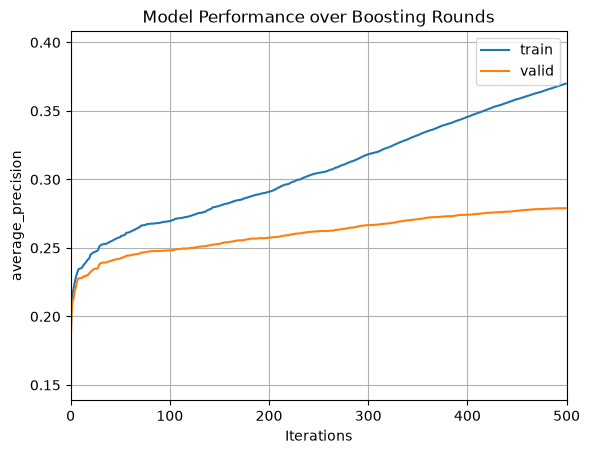

Using validation set to get metrics...
Optimal Threshold: 0.6527
Max F1 Score:      0.3373
Precision at Max:  0.2701
Recall at Max:     0.4490
ROC AUC Score:     0.7903


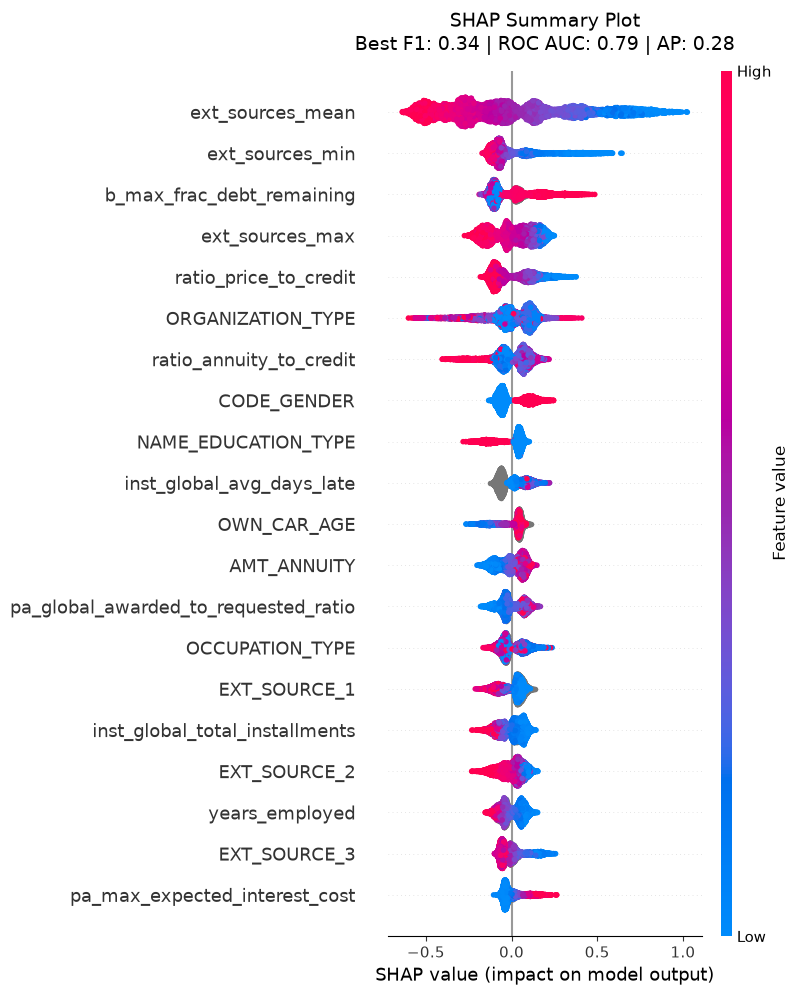

ext_sources_mean                        0.316594
ext_sources_min                         0.109338
b_max_frac_debt_remaining               0.108812
ext_sources_max                         0.108139
ratio_price_to_credit                   0.103736
ORGANIZATION_TYPE                       0.101722
ratio_annuity_to_credit                 0.079834
CODE_GENDER                             0.078215
NAME_EDUCATION_TYPE                     0.069938
inst_global_avg_days_late               0.065757
OWN_CAR_AGE                             0.063623
AMT_ANNUITY                             0.062552
pa_global_awarded_to_requested_ratio    0.059260
OCCUPATION_TYPE                         0.059153
EXT_SOURCE_1                            0.058075
inst_global_total_installments          0.058037
EXT_SOURCE_2                            0.057147
years_employed                          0.056847
EXT_SOURCE_3                            0.051995
Name: mean_abs_shap, dtype: float64

In [62]:
probed_baseline_model, probed_baseline_shap_importance, pos_weight_ = run_lightgbm(probed_baseline_train, cat_cols)

# Probe Thresholds (SHAP)

The SHAP values have been generated for the baseline model which includes the noise probes. Therefore, these can be interrogated to get the SHAP value thresholds for each type of feature in the master datasets.

Any features falling below the threshold are dropped.

In [63]:
#list of strings of probe feature names

continuous_probes = [name for name in probed_baseline_shap_importance.index if name.startswith("probe_continuous_")]

categorical_probes = [name for name in probed_baseline_shap_importance.index if name.startswith("probe_categorical_")]

boolean_probes = [name for name in probed_baseline_shap_importance.index if name.startswith("probe_boolean_")]

count_probes = [name for name in probed_baseline_shap_importance.index if name.startswith("probe_count_")]

print(f"Continuous Probes: {continuous_probes}")
print(f"Categorical Probes: {categorical_probes}")
print(f"Boolean Probes: {boolean_probes}")
print(f"Count Probes: {count_probes}")
print()
print(f"Total fields included are {len(continuous_probes + categorical_probes + boolean_probes + count_probes)}") #for validation

Continuous Probes: ['probe_continuous_uniform_3', 'probe_continuous_gaussian_4', 'probe_continuous_gaussian_2', 'probe_continuous_gaussian_0', 'probe_continuous_uniform_1']
Categorical Probes: ['probe_categorical_0', 'probe_categorical_1', 'probe_categorical_2', 'probe_categorical_3', 'probe_categorical_4']
Boolean Probes: ['probe_boolean_4', 'probe_boolean_1', 'probe_boolean_0', 'probe_boolean_2', 'probe_boolean_3']
Count Probes: ['probe_count_poisson_4', 'probe_count_poisson_2', 'probe_count_poisson_0', 'probe_count_poisson_3', 'probe_count_poisson_1']

Total fields included are 20


In [64]:
#define thresholds for each probe type
cutoff_percentile = 0.95

thresholds = {
    "continuous": probed_baseline_shap_importance.loc[continuous_probes].quantile(cutoff_percentile), #takes percentile shap value from the continuous subset of shap_importance
    "categorical": probed_baseline_shap_importance.loc[categorical_probes].quantile(cutoff_percentile),
    "boolean": probed_baseline_shap_importance.loc[boolean_probes].quantile(cutoff_percentile),
    "count": probed_baseline_shap_importance.loc[count_probes].quantile(cutoff_percentile)}

In [65]:
bool_cols_no_target = [feature for feature in bool_cols if feature != "TARGET"]

print(f"Boolean Columns: {bool_cols_no_target}")
print(f"Continuous Columns: {contin_cols}")
print(f"Categoric Columns: {cat_cols}")
print(f"Count Columns: {count_cols}")
print()

feature_groups = {
    "continuous": contin_cols,
    "categorical": cat_cols,
    "boolean": bool_cols_no_target,
    "count": count_cols}

features_to_drop = {}

for feature_type, feature_names in feature_groups.items():

    cutoff = thresholds[feature_type]
    dropped_features = []

    for feature_name in feature_names:
      importance = probed_baseline_shap_importance[feature_name] #access via string index defined before

      if importance <= cutoff:
        dropped_features.append(feature_name) #if shap below threshold then add to drop list

    features_to_drop[feature_type] = dropped_features #new key for the category with values being list of features to drop


print("Features to drop (dict):")
print(features_to_drop)

probe_col_to_drop = []

for feature_type, features in features_to_drop.items():
    probe_col_to_drop.extend(features)

print()
print(f"{len(probe_col_to_drop)} features to drop:")
print(*sorted(probe_col_to_drop), sep='\n')

Boolean Columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EMERGENCYSTATE_MODE', 'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'flag_employed_anomaly', 'b_any_current_debt', 'b_any_currently_overdue', 'bb_any_historical_dpd', 'bb_any_closed_history', 'bb_any_unknown_history', 'bb_any_severe_default', 'bb_any_balance_history_available', 'pa_most_recent_app_was_rejected', 'p

In [66]:
master_train_denoise = master_train_all.drop_columns(probe_col_to_drop)
master_test_denoise = master_test_all.drop_columns(probe_col_to_drop)

In [67]:
denoise_cat_cols = [col for col in cat_cols if col not in probe_col_to_drop]

TARGET Imbalance: 11.36:1


Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[500]	train's average_precision: 0.291812	valid's average_precision: 0.271842
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[497]	train's average_precision: 0.317081	valid's average_precision: 0.276116
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[500]	train's average_precision: 0.36137	valid's average_precision: 0.277703
Best Validation Average Precision: 0.2777032183387286 (with 127 leaves)


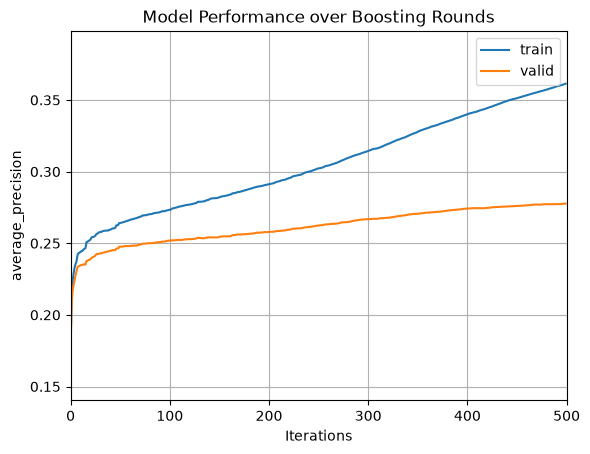

Using validation set to get metrics...
Optimal Threshold: 0.6364
Max F1 Score:      0.3391
Precision at Max:  0.2597
Recall at Max:     0.4881
ROC AUC Score:     0.7910


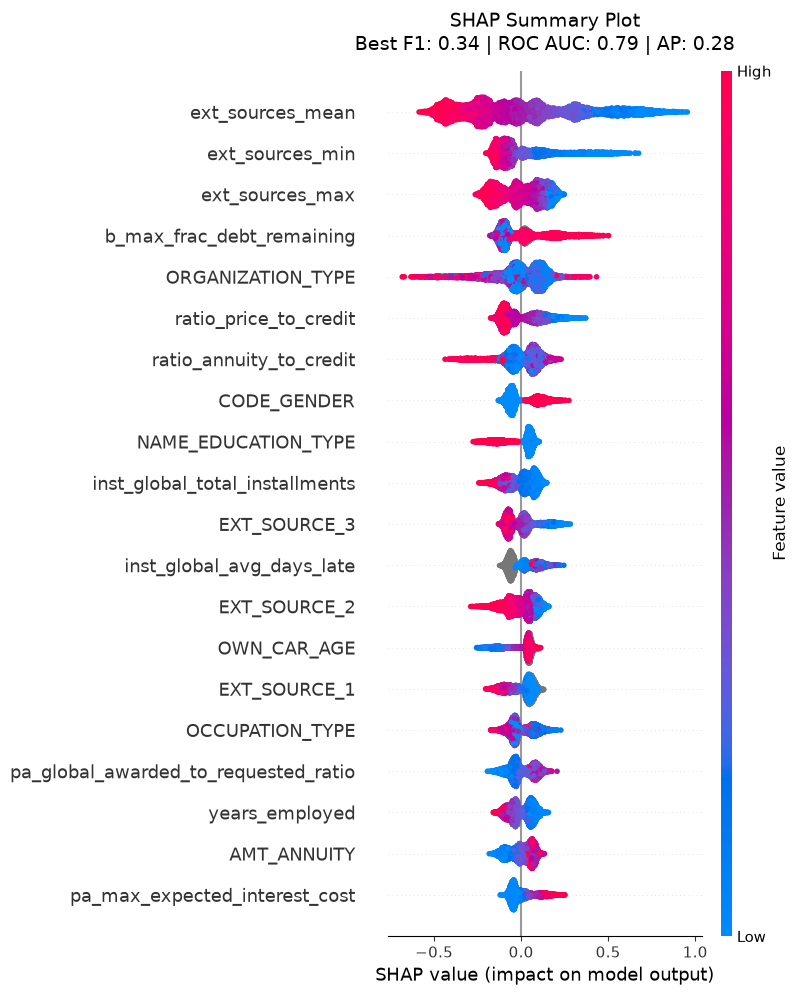

ext_sources_mean                        0.274415
ext_sources_min                         0.123859
ext_sources_max                         0.110525
b_max_frac_debt_remaining               0.109146
ORGANIZATION_TYPE                       0.104833
ratio_price_to_credit                   0.098413
ratio_annuity_to_credit                 0.079452
CODE_GENDER                             0.077644
NAME_EDUCATION_TYPE                     0.075764
inst_global_total_installments          0.066836
EXT_SOURCE_3                            0.066720
inst_global_avg_days_late               0.065554
EXT_SOURCE_2                            0.065377
OWN_CAR_AGE                             0.063408
EXT_SOURCE_1                            0.062710
OCCUPATION_TYPE                         0.060821
pa_global_awarded_to_requested_ratio    0.060449
years_employed                          0.058308
AMT_ANNUITY                             0.056009
Name: mean_abs_shap, dtype: float64

In [68]:
denoise_model, denoise_shap_importance, _ = run_lightgbm(master_train_denoise, denoise_cat_cols)

# Spearman Correlation

Whilst not always neccesary here since multicollinearity does not invalidate LightGBM models, pruning highly correlated features can make models simpler, more explainable, with greater SHAP value stability.

The trade-off is potential performance degredation. As such, highly correlated features will be identified and dropped with model performance compared. If only a minor degredation in performance, features can be dropped. Otherwise, the correlated features can persist to enable optimal performance.

In [69]:
def find_correlated_features_to_drop(table: pa.Table, shap_importance, threshold = 0.90, sample_size = 100000, random_state = 42):

  table = table.drop_columns(["TARGET"])

  if table.num_rows > sample_size:
    rng = np.random.default_rng(random_state)
    row_indices = rng.choice(table.num_rows, size=sample_size,  replace=False)
    sampled_table = table.take(row_indices)

  else:
    sampled_table = table

  df = sampled_table.to_pandas()

  correlation_matrix = df.corr(method="spearman").abs()

  ordered_features = sorted(table.column_names, key=lambda feature: shap_importance[feature], reverse=True)

  kept_features = []
  features_to_drop = []

  for feature in ordered_features:
    highly_correlated_with_kept_feature = False

    for kept_feature in kept_features:
      correlation = correlation_matrix.loc[feature, kept_feature]

      if correlation >= threshold:
        highly_correlated_with_kept_feature = True
        break

    if highly_correlated_with_kept_feature:
      features_to_drop.append(feature)

    else:
      kept_features.append(feature)

  return features_to_drop

In [70]:
highly_correlated_features_to_drop = find_correlated_features_to_drop(master_train_denoise, denoise_shap_importance, threshold=0.90, sample_size=100000, random_state=42)

In [71]:
print(highly_correlated_features_to_drop)
print(len(highly_correlated_features_to_drop))

['inst_global_worst_days_late', 'DAYS_EMPLOYED', 'ratio_life_employed', 'age_in_years', 'AMT_CREDIT', 'b_total_max_overdue_amt_ever', 'pa_global_amt_awarded', 'inst_global_payment_ratio', 'b_avg_frac_paid_or_not_os', 'b_avg_credit_sum', 'b_avg_current_debt', 'b_total_credit_sum', 'REGION_RATING_CLIENT', 'b_closed_loans']
14


In [72]:
master_train_denoise_uncorr = master_train_denoise.drop_columns(highly_correlated_features_to_drop)
master_test_denoise_uncorr = master_test_denoise.drop_columns(highly_correlated_features_to_drop)

print(f"Before: {master_train_denoise.shape}")
print(f"After: {master_train_denoise_uncorr.shape}")

Before: (307511, 111)
After: (307511, 97)


In [73]:
denoise_uncorr_cat_cols = [col for col in denoise_cat_cols if col not in highly_correlated_features_to_drop]

TARGET Imbalance: 11.36:1
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[499]	train's average_precision: 0.290274	valid's average_precision: 0.271756
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[499]	train's average_precision: 0.315898	valid's average_precision: 0.274832
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[497]	train's average_precision: 0.358793	valid's average_precision: 0.278512
Best Validation Average Precision: 0.27851206902144177 (with 127 leaves)


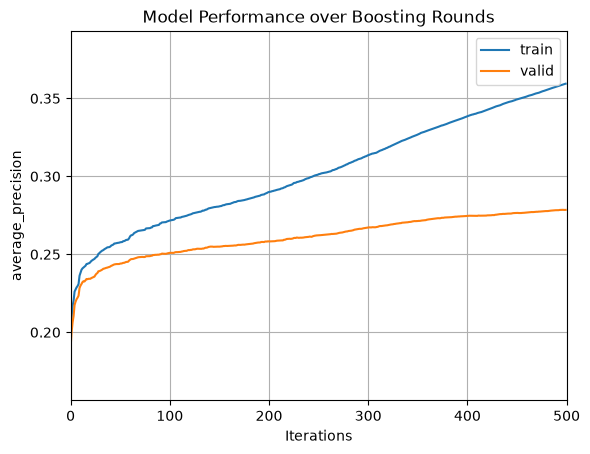

Using validation set to get metrics...
Optimal Threshold: 0.6590
Max F1 Score:      0.3380
Precision at Max:  0.2720
Recall at Max:     0.4463
ROC AUC Score:     0.7906


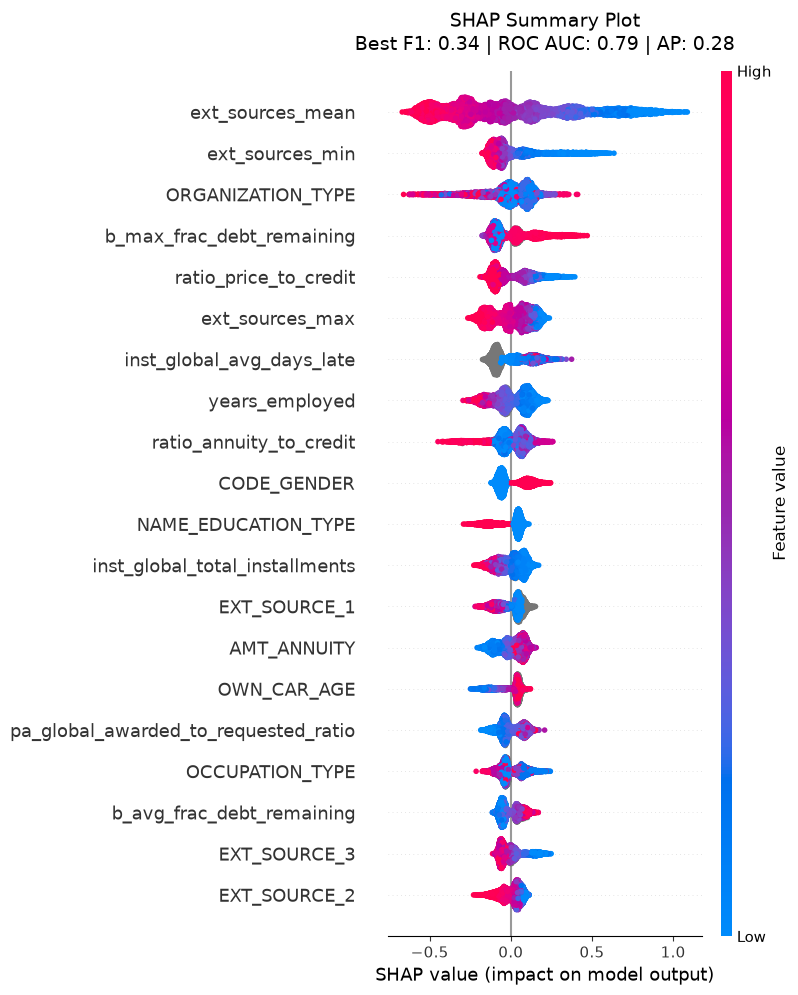

ext_sources_mean                        0.325367
ext_sources_min                         0.106360
ORGANIZATION_TYPE                       0.103219
b_max_frac_debt_remaining               0.102777
ratio_price_to_credit                   0.101947
ext_sources_max                         0.100568
inst_global_avg_days_late               0.098344
years_employed                          0.092613
ratio_annuity_to_credit                 0.078198
CODE_GENDER                             0.078149
NAME_EDUCATION_TYPE                     0.072456
inst_global_total_installments          0.066884
EXT_SOURCE_1                            0.066057
AMT_ANNUITY                             0.065386
OWN_CAR_AGE                             0.062542
pa_global_awarded_to_requested_ratio    0.061355
OCCUPATION_TYPE                         0.060811
b_avg_frac_debt_remaining               0.055683
EXT_SOURCE_3                            0.053557
Name: mean_abs_shap, dtype: float64

In [74]:
denoise_uncorr_model, denoise_uncorr_shap_importance, _ = run_lightgbm(master_train_denoise_uncorr, denoise_uncorr_cat_cols)

# Protected Attributes

The original training dataset had ~280 features. Around 2/3 of these were pruned by comparing SHAP values with noise probes, and a further few removed as they were highly correlated with a remaining feature with higher SHAP value, leaving around 80 features. Removing these ~200 features did not significantly degrade performance, leaving a simpler and more explainable prediction model.

However, UK regulations, such as the 2010 Equality Act, FCA's Consumer Duty principle, and GDPR, legally forbid the use of protected attributes to promote fairness and combat discriminatory decision making processes.

Prottected attributes are those which contain personal and/or demographic information, whether directly or indirectly as a proxy variable. Models can learn to use these features to derive a predictive signal so should be dropped before models are trained.

Whilst this will degrade model performance, there is no point in having a better model that can' be deployed since it is discriminatory and an unexplainable "black-box".

The majority of the original ~280 features are allowed since they provide unbiased behavioural signals, but protected variables must be identified and dropped.

**Protected Attributes to Remove**


- **Socio-economic proxies:**
  - All housing quality metrics e.g. those ending with `_AVG`, `_MODE`, or `_MEDI`
  - Geographic location metrics e.g. `REGION_RATING_CLIENT` and `REGION_RATING_CLIENT_WITH_CITY`
  - Population density metrics e.g. `REGION_POPULATION_RELATIVE`
  - Acquired Education e.g. `NAME_EDUCATION_TYPE` and by association `index_wealth_stability`, which is derived from the prior


- **Personal Features:**
  - Sex e.g. `CODE_GENDER`
  - Age e.g. `DAYS_BIRTH` and engineered features that leak age (`age_in_years` and `ratio_life_employed`)
  - Marital Status e.g. `NAME_FAMILY_STATUS`
  - Maternity/Paternity e.g. `CNT_CHILDREN` and `CNT_FAM_MEMBERS`

- **Guilt by Association:**
  - Social circle metrics e.g. `OBS_30_CNT_SOCIAL_CIRCLE`, `OBS_60_CNT_SOCIAL_CIRCLE`, `DEF_30_CNT_SOCIAL_CIRCLE`, and `DEF_60_CNT_SOCIAL_CIRCLE` where decisions are not based solely on the individual

**A Note on Retained Features:**
* **Geographic Mismatches:** Flags mapping discrepancies between live/work locations (e.g., `REG_REGION_NOT_LIVE_REGION`) are kept as behavioral/transiency indicators rather than demographic proxies.
* **External Scores:** Aggregated bureau scores (`EXT_SOURCE_1`, `EXT_SOURCE_2`, and `EXT_SOURCE_3`) are highly predictive and chosen to be kept. Whilst these "black boxes" may contain systemic biases, they are industry-standard risk metrics which contain significant predictive signal that cannot be decomposed here. These are analogous to credit report derives scores provided by CRAs such as Experian, Equifax, and TransUnion.

In [75]:
all_cols_no_target = [feature for feature in master_train_all.column_names if feature != "TARGET"]

denoise_uncorr_cols = master_train_denoise_uncorr.column_names

print(denoise_uncorr_cols)
print(len(denoise_uncorr_cols))

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_CITY_NOT_LIVE_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'WALLSMATERIAL_MODE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_3', 'AMT_REQ_CREDIT_BUREAU_QRT', 'ratio_debt_to_income', 'ratio_annuity_to_income', 'ratio_annuity_to_credit', 'ratio_price_to_credit', 'years_employed', 'ext_sources_null_count', 'ext_sources_mean', 'ext_sources_min', 'ext_sources_max', 'ext_sources_variance', 'index_wealth_stability', 'b_

In [76]:
housing_cols = [feature for feature in all_cols_no_target if feature.endswith(('_AVG', '_MODE', '_MEDI'))] #those that still persist
association_cols = [feature for feature in all_cols_no_target if feature.endswith('_CNT_SOCIAL_CIRCLE')] #those that still persist
print(f"Housing:\n{housing_cols}")
print(f"Association:\n{association_cols}")

Housing:
['APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Association:
['OBS_

In [77]:
other_protected_attributes = ["CODE_GENDER", "DAYS_BIRTH", "age_in_years", "ratio_life_employed",
                              "NAME_EDUCATION_TYPE", "index_wealth_stability","REGION_POPULATION_RELATIVE", "REGION_RATING_CLIENT",
                              "REGION_RATING_CLIENT_WITH_CITY", "NAME_FAMILY_STATUS", "CNT_CHILDREN", "CNT_FAM_MEMBERS"]

In [78]:
all_potential_protected_attributes = housing_cols + association_cols + other_protected_attributes
print(len(all_potential_protected_attributes))

63


In [79]:
protected_attributes_to_drop = [feature for feature in denoise_uncorr_cols if feature in all_potential_protected_attributes] #protected attributes that persist through denoise and uncorrelation steps
print(f"There are {len(protected_attributes_to_drop)} predictive features to drop for fairness which haven't been dropped based on SHAP noise probes/correlation:\n{protected_attributes_to_drop}")

protected_attr_already_dropped = [col for col in denoise_uncorr_cols if col not in all_potential_protected_attributes] #protected attributes that were removed through denoise and uncorrelation steps

There are 10 predictive features to drop for fairness which haven't been dropped based on SHAP noise probes/correlation:
['CODE_GENDER', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'CNT_FAM_MEMBERS', 'WALLSMATERIAL_MODE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'index_wealth_stability']


In [80]:
final_train = master_train_denoise_uncorr.drop_columns(protected_attributes_to_drop)
final_test = master_test_denoise_uncorr.drop_columns(protected_attributes_to_drop)

print(f"Final train shape: {final_train.shape}")
print(f"Final test shape: {final_test.shape}")

Final train shape: (307511, 87)
Final test shape: (48744, 86)


In [81]:
final_cat_cols = [col for col in denoise_uncorr_cat_cols if col not in protected_attributes_to_drop]

TARGET Imbalance: 11.36:1
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[499]	train's average_precision: 0.28574	valid's average_precision: 0.266578
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[500]	train's average_precision: 0.309301	valid's average_precision: 0.270556
Training until validation scores don't improve for 15 rounds
Did not meet early stopping. Best iteration is:
[500]	train's average_precision: 0.349881	valid's average_precision: 0.272869
Best Validation Average Precision: 0.27286948161013025 (with 127 leaves)


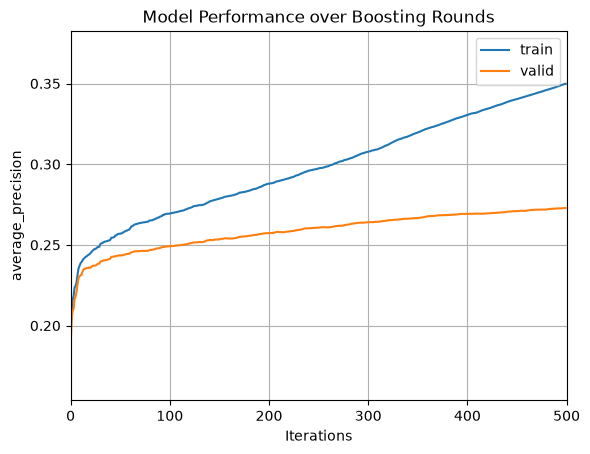

Using validation set to get metrics...
Optimal Threshold: 0.6704
Max F1 Score:      0.3323
Precision at Max:  0.2743
Recall at Max:     0.4212
ROC AUC Score:     0.7867


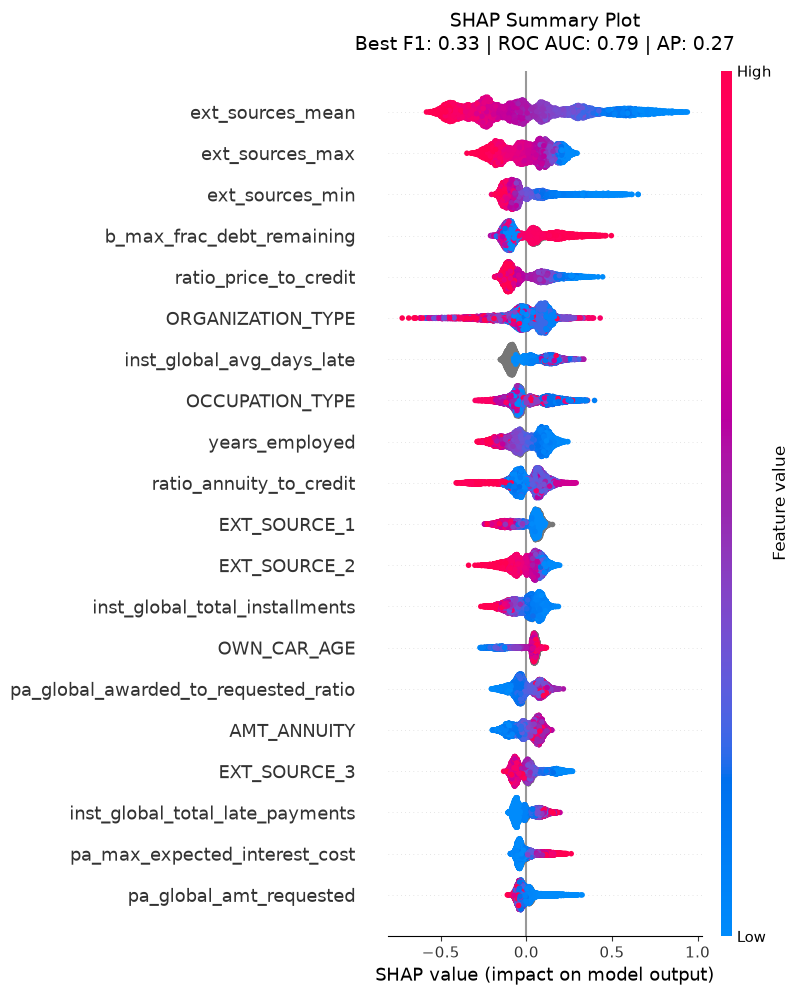

ext_sources_mean                        0.276734
ext_sources_max                         0.123951
ext_sources_min                         0.115769
b_max_frac_debt_remaining               0.113326
ratio_price_to_credit                   0.109517
ORGANIZATION_TYPE                       0.106720
inst_global_avg_days_late               0.095549
OCCUPATION_TYPE                         0.093065
years_employed                          0.092091
ratio_annuity_to_credit                 0.083644
EXT_SOURCE_1                            0.074478
EXT_SOURCE_2                            0.070478
inst_global_total_installments          0.068965
OWN_CAR_AGE                             0.068876
pa_global_awarded_to_requested_ratio    0.065722
AMT_ANNUITY                             0.064381
EXT_SOURCE_3                            0.060565
inst_global_total_late_payments         0.058439
pa_max_expected_interest_cost           0.048611
Name: mean_abs_shap, dtype: float64

In [82]:
final_model, final_shap_importance, _ = run_lightgbm(final_train, final_cat_cols)

# Bayesian Hyperparameter Optimisation (Optuna)

In [83]:
def objective(trial):
    #define the search space dynamically
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'scale_pos_weight': pos_weight, #from before
        'verbose': -1,
        'device':'gpu',

        #hyperparameters to tune
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 100, 1000),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 0.9),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 0.9),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True)}

    pruning_callback = LightGBMPruningCallback(trial, 'average_precision', valid_name='valid')

    #train the model using the trial's parameters
    model = lgb.train(
        params,
        dtrain,
        valid_sets=[dtrain, dval],
        valid_names=['train', 'valid'],
        num_boost_round=1500,
        callbacks=[
            lgb.early_stopping(stopping_rounds=15, verbose=False),
            pruning_callback])

    #return the metric you want to optimize
    return model.best_score['valid']['average_precision']

#create the study and run 30 trials
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner(n_warmup_steps=20))
study.optimize(objective, n_trials=30)

print(f"Best Validation Average Precision: {study.best_value}")
print("Optimal Parameters:")
for key, value in study.best_params.items():
    print(f"    '{key}': {value},")

[I 2026-09-25 19:56:36,129] A new study created in memory with name: no-name-9af7ea8c-d3b0-4234-8288-f8fa404108d3
[W 2026-09-25 19:56:36,130] Trial 0 failed with parameters: {} because of the following error: NameError("name 'pos_weight' is not defined").
Traceback (most recent call last):
  File "/home/ubuntu/git-repo/credit-risk-prediction-lightgbm/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_7941/1238037368.py", line 6, in objective
    'scale_pos_weight': pos_weight, #from before
                        ^^^^^^^^^^
NameError: name 'pos_weight' is not defined. Did you mean: 'pos_weight_'?
[W 2026-09-25 19:56:36,133] Trial 0 failed with value None.


NameError: name 'pos_weight' is not defined

In [ ]:
#extract winning hyperparameters from optuna
final_params = study.best_params

# Add back untuned structural parameters
final_params['objective'] = 'binary'
final_params['metric'] = 'average_precision'
final_params['scale_pos_weight'] = pos_weight
final_params['verbose'] = -1
final_params['device'] = 'gpu'

final_model, final_shap_importance, _ = run_lightgbm(final_train, final_cat_cols, final_params)